# Hotel Booking & Inventory Analysis

**Python • Pandas • Matplotlib**

This portfolio project analyses a synthetic 13-unit resort dataset covering **January 2025 to August 2026**.

The objective is to understand inventory utilisation, realised revenue, occupancy, ADR, RevPAR, booking-channel behaviour, cancellations, and booking lead time.


## 1. Data Loading

The project uses two source datasets:

- `hotel_bookings.csv` — one row per booking
- `room_inventory.csv` — one row per accommodation category

Dates are parsed during import so they can be used directly for time-based analysis.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

bookings = pd.read_csv(
    "data/hotel_bookings.csv",
    parse_dates=["booking_date", "check_in", "check_out"]
)

inventory = pd.read_csv("data/room_inventory.csv")

print("Bookings shape:", bookings.shape)
print("Inventory shape:", inventory.shape)

bookings.head()


Bookings shape: (4476, 11)
Inventory shape: (4, 3)


,booking_id,booking_date,check_in,check_out,room_type,channel,lead_time_days,nights,nightly_rate,cancelled,booking_value
0,B00001,2024-12-10,2025-01-01,2025-01-03,Cottage,Direct,22,2,5428.20,False,10856.40
1,B00002,2024-12-21,2025-01-01,2025-01-02,Cottage,Direct,11,1,5478.93,False,5478.93
2,B00003,2024-12-15,2025-01-01,2025-01-04,Cottage,MakeMyTrip,17,3,5381.83,False,16145.49
3,B00004,2024-12-09,2025-01-01,2025-01-04,Cottage,Booking.com,23,3,5387.16,True,16161.48
4,B00005,2024-11-24,2025-01-01,2025-01-04,Villa,Booking.com,38,3,11259.63,False,33778.89


## 2. Data Quality Checks

Before calculating KPIs, the data is checked for duplicate booking IDs, missing values, data types, and basic date consistency.

A booking ID should represent one unique booking.


In [3]:
print("Duplicate booking IDs:", bookings["booking_id"].duplicated().sum())

print("\nMissing values:")
print(bookings.isna().sum())

print("\nData types:")
print(bookings.dtypes)

invalid_dates = (bookings["check_out"] <= bookings["check_in"]).sum()
print("\nBookings with check-out on/before check-in:", invalid_dates)


Duplicate booking IDs: 0

Missing values:
booking_id        0
booking_date      0
check_in          0
check_out         0
room_type         0
channel           0
lead_time_days    0
nights            0
nightly_rate      0
cancelled         0
booking_value     0
dtype: int64

Data types:
booking_id                   str
booking_date      datetime64[us]
check_in          datetime64[us]
check_out         datetime64[us]
room_type                    str
channel                      str
lead_time_days             int64
nights                     int64
nightly_rate             float64
cancelled                   bool
booking_value            float64
dtype: object

Bookings with check-out on/before check-in: 0


## 3. Inventory Overview

The property contains **13 accommodation units** across Cottage, Villa, Dormitory, and Camping Tent categories.

Inventory is required to calculate available room nights and occupancy rather than relying only on booking counts.


In [4]:
inventory


,room_type,units,base_rate
0,Cottage,8,5200
1,Villa,1,10500
2,Dormitory,2,2200
3,Camping Tent,2,2800


In [5]:
total_units = inventory["units"].sum()
print("Total accommodation units:", total_units)


Total accommodation units: 13


## 4. Data Preparation

Cancelled bookings are useful for channel and cancellation analysis, but they should not contribute to realised occupancy or realised room revenue.

For operating KPIs, a separate `active` dataset is therefore created containing non-cancelled bookings only.


In [6]:
active = bookings.loc[~bookings["cancelled"]].copy()

active["month"] = active["check_in"].dt.to_period("M").astype(str)
active["revenue"] = active["booking_value"]

print("All bookings:", len(bookings))
print("Non-cancelled bookings:", len(active))
print("Cancelled bookings:", bookings["cancelled"].sum())


All bookings: 4476
Non-cancelled bookings: 3945
Cancelled bookings: 531


## 5. Monthly Occupancy, ADR & RevPAR

Three core hotel KPIs are calculated:

- **Occupancy %** = Sold room nights ÷ Available room nights
- **ADR** = Average Daily Rate / average realised nightly rate
- **RevPAR** = Realised room revenue ÷ Available room nights

Available room nights are calculated from the property's 13 units and the number of calendar days in each month.


In [7]:
monthly = (
    active.groupby("month")
    .agg(
        bookings=("booking_id", "count"),
        room_nights=("nights", "sum"),
        revenue=("revenue", "sum"),
        adr=("nightly_rate", "mean")
    )
    .reset_index()
)

monthly["days"] = pd.to_datetime(monthly["month"] + "-01").dt.days_in_month
monthly["available_room_nights"] = monthly["days"] * total_units
monthly["occupancy_pct"] = (
    100 * monthly["room_nights"] / monthly["available_room_nights"]
)
monthly["revpar"] = monthly["revenue"] / monthly["available_room_nights"]

monthly.round(2)


,month,bookings,room_nights,revenue,adr,days,available_room_nights,occupancy_pct,revpar
0,2025-01,193,370,1936640.42,5153.46,31,403,91.81,4805.56
1,2025-02,165,315,1737616.70,5295.13,28,364,86.54,4773.67
2,2025-03,175,358,1801894.53,5057.25,31,403,88.83,4471.20
3,2025-04,154,326,1499043.65,4627.79,30,390,83.59,3843.70
4,2025-05,163,331,1528816.23,4802.06,31,403,82.13,3793.59
5,2025-06,192,370,1928989.14,5126.17,30,390,94.87,4946.13
6,2025-07,192,398,2148973.93,5387.41,31,403,98.76,5332.44
7,2025-08,223,451,2440588.58,5388.05,31,403,111.91,6056.05
8,2025-09,177,327,1673445.32,5141.90,30,390,83.85,4290.89
9,2025-10,236,441,2615104.02,5840.31,31,403,109.43,6489.09


### Occupancy Trend

Occupancy is plotted over time to identify seasonality and periods of stronger or weaker inventory utilisation.


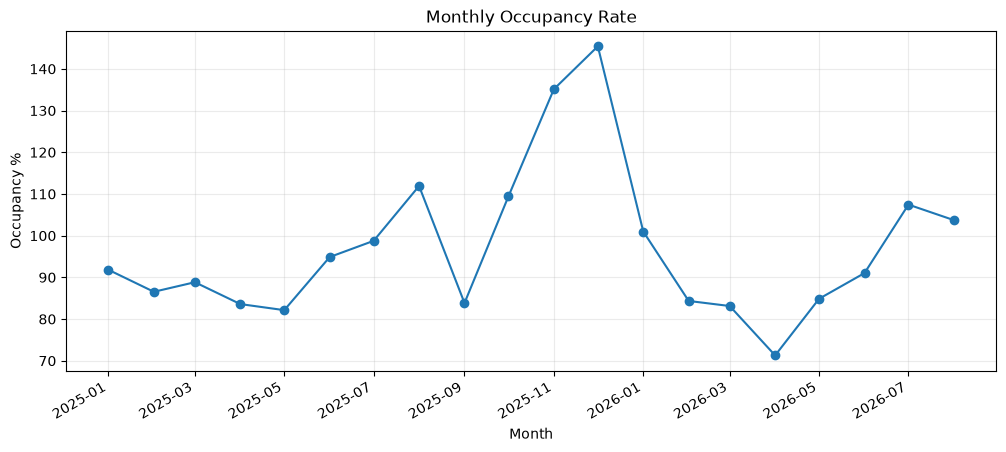

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

x = pd.to_datetime(monthly["month"] + "-01")

ax.plot(x, monthly["occupancy_pct"], marker="o")
ax.set_title("Monthly Occupancy Rate")
ax.set_xlabel("Month")
ax.set_ylabel("Occupancy %")
ax.grid(alpha=0.25)

fig.autofmt_xdate()
plt.show()


### ADR and RevPAR Trend

ADR shows the average realised nightly rate, while RevPAR combines room revenue with available inventory. Looking at both helps distinguish pricing performance from inventory utilisation.


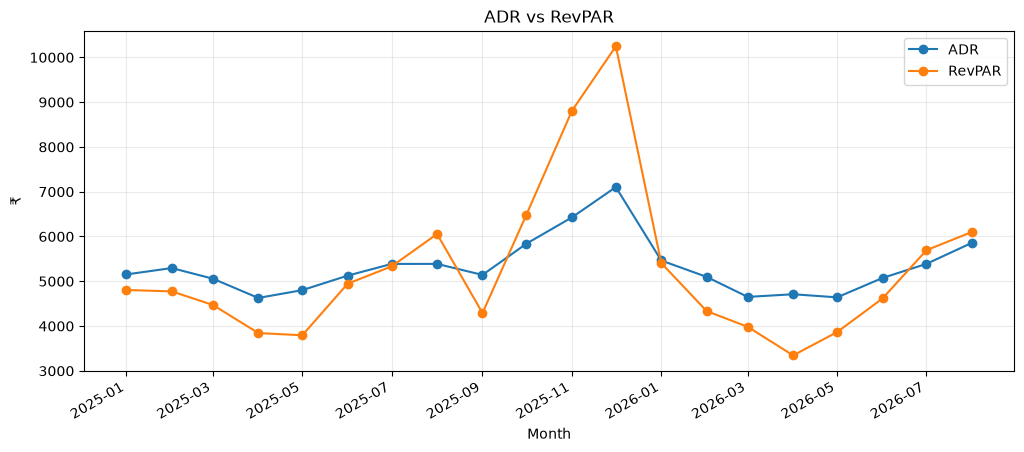

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(x, monthly["adr"], marker="o", label="ADR")
ax.plot(x, monthly["revpar"], marker="o", label="RevPAR")

ax.set_title("ADR vs RevPAR")
ax.set_xlabel("Month")
ax.set_ylabel("₹")
ax.legend()
ax.grid(alpha=0.25)

fig.autofmt_xdate()
plt.show()


## 6. Booking Channel Analysis

Channel analysis compares booking volume, cancellation rate, average lead time, and booking value across Direct, Booking.com, MakeMyTrip, and Agoda.

Cancellation rate is calculated using all bookings because cancelled reservations are themselves part of the behaviour being measured.


In [10]:
channel = (
    bookings.groupby("channel")
    .agg(
        bookings=("booking_id", "count"),
        cancellation_rate=("cancelled", "mean"),
        avg_lead_time=("lead_time_days", "mean"),
        gross_booking_value=("booking_value", "sum")
    )
    .reset_index()
)

channel["cancellation_rate"] *= 100

channel.round(2).sort_values("bookings", ascending=False)


,channel,bookings,cancellation_rate,avg_lead_time,gross_booking_value
2,Direct,1732,7.16,11.54,18407481.22
1,Booking.com,1150,15.91,19.82,12033020.91
3,MakeMyTrip,1096,11.95,19.51,11640500.08
0,Agoda,498,18.67,19.63,5198070.29


### Cancellation Rate by Channel


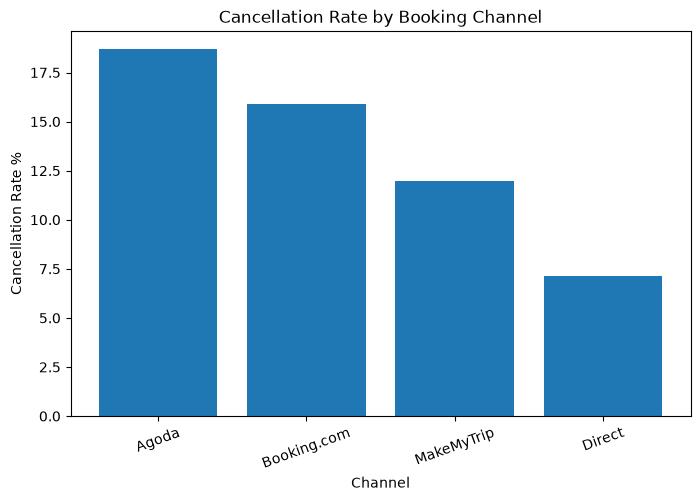

In [11]:
channel_sorted = channel.sort_values("cancellation_rate", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(channel_sorted["channel"], channel_sorted["cancellation_rate"])
ax.set_title("Cancellation Rate by Booking Channel")
ax.set_xlabel("Channel")
ax.set_ylabel("Cancellation Rate %")

plt.xticks(rotation=20)
plt.show()


### Booking Lead Time by Channel

Lead time measures the number of days between booking creation and check-in. Differences between channels can help with forecasting and inventory planning.


In [12]:
lead_time = (
    bookings.groupby("channel")["lead_time_days"]
    .mean()
    .sort_values(ascending=False)
)

lead_time.round(2)


channel
Booking.com    19.82
Agoda          19.63
MakeMyTrip     19.51
Direct         11.54
Name: lead_time_days, dtype: float64

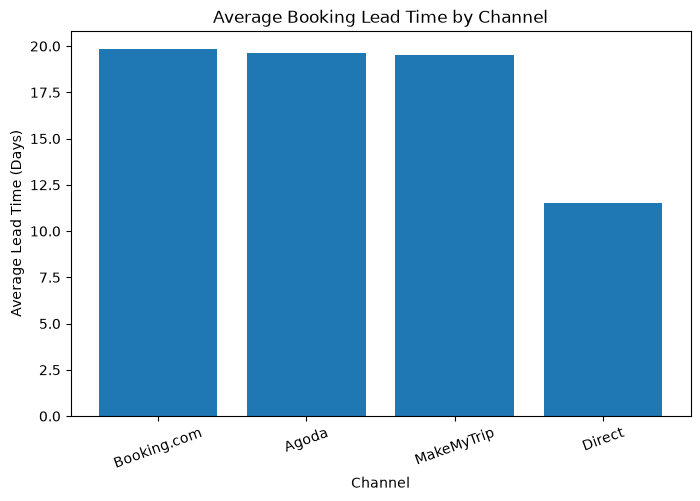

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(lead_time.index, lead_time.values)
ax.set_title("Average Booking Lead Time by Channel")
ax.set_xlabel("Channel")
ax.set_ylabel("Average Lead Time (Days)")

plt.xticks(rotation=20)
plt.show()


## 7. Room-Type Performance

Room categories are compared using realised booking volume, room nights, revenue, ADR, and average booking value.


In [14]:
room_performance = (
    active.groupby("room_type")
    .agg(
        bookings=("booking_id", "count"),
        room_nights=("nights", "sum"),
        revenue=("revenue", "sum"),
        adr=("nightly_rate", "mean"),
        avg_booking_value=("booking_value", "mean")
    )
    .reset_index()
)

room_performance.round(2).sort_values("revenue", ascending=False)


,room_type,bookings,room_nights,revenue,adr,avg_booking_value
1,Cottage,2563,4985,29194850.21,5860.34,11390.89
3,Villa,273,540,6402933.19,11868.95,23453.97
0,Camping Tent,523,1013,3240659.87,3200.11,6196.29
2,Dormitory,586,1137,2813232.50,2486.81,4800.74


## 8. Key Findings


In [15]:
best_month = monthly.loc[monthly["occupancy_pct"].idxmax()]
lowest_month = monthly.loc[monthly["occupancy_pct"].idxmin()]
highest_cancel = channel.loc[channel["cancellation_rate"].idxmax()]
direct = channel.loc[channel["channel"] == "Direct"].iloc[0]

print(
    f"Highest monthly occupancy: {best_month['occupancy_pct']:.1f}% "
    f"in {best_month['month']}."
)

print(
    f"Lowest monthly occupancy: {lowest_month['occupancy_pct']:.1f}% "
    f"in {lowest_month['month']}."
)

print(
    f"Highest cancellation rate: {highest_cancel['channel']} "
    f"at {highest_cancel['cancellation_rate']:.1f}%."
)

print(
    f"Direct booking cancellation rate: "
    f"{direct['cancellation_rate']:.1f}%."
)


Highest monthly occupancy: 145.4% in 2025-12.
Lowest monthly occupancy: 71.3% in 2026-04.
Highest cancellation rate: Agoda at 18.7%.
Direct booking cancellation rate: 7.2%.


### Interpretation

The analysis highlights three operational themes:

1. **Inventory utilisation is seasonal.** Occupancy varies meaningfully across the analysis period, so booking count alone does not fully describe property performance.

2. **Booking channels behave differently.** OTA channels show different cancellation and lead-time patterns from Direct bookings, which matters for forecasting and inventory control.

3. **Occupancy, ADR, and RevPAR should be interpreted together.** A high nightly rate does not automatically mean strong inventory performance, while occupancy alone does not capture pricing quality.

The dataset is synthetic and does not contain operational variables such as marketing campaigns, local events, competitor pricing, or channel commissions. The analysis therefore identifies patterns in booking behaviour without claiming unsupported causes.


## 9. Project Summary

This project demonstrates an end-to-end Python analytics workflow:

**CSV data → Pandas validation and preparation → aggregation → hotel KPIs → exploratory analysis → Matplotlib visualisation → business interpretation**

The complete source datasets are available in the repository's `data/` directory.
